# Donor Retention Project Logistic Regression 
## Ian Kimura

#### Project Objective: Predict which donors are likely to stop contributing based on historical data using logistic regression.


In [1]:
# Import necessary libraries
import pandas as pd
from datetime import timedelta
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

## Let's look at the dataset

In [2]:
# Reading the dataset into a dataframe
df = pd.read_csv('/users/iankimura/Documents/DS_INTERN/usf_aa_giving_test.csv')
df.head()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp
0,0013i0000243bmjAAA,0033i000024DCfLAAW,0.0,50000.0,50000.0,1978,1/1/1978,Father William Dunne Scholarship,Household Gift
1,0013i0000243bmjAAA,0033i000024EszaAAC,0.0,50000.0,0.0,1978,1/1/1978,Father William Dunne Scholarship,Household Gift
2,0013i000023HTCyAAO,0033i000024EbfIAAS,1.0,25.0,25.0,1980,12/21/1979,KUSF Program Underwriting,Household Gift
3,0013i0000243kC0AAI,0033i000024Eb2qAAC,0.0,120.0,0.0,1981,3/12/1981,School of Law Assembly,Household Gift
4,0013i000023Hj4sAAC,0033i000024EAhIAAW,0.0,10.0,10.0,1981,4/10/1981,The USF Fund,Household Gift


We can see that this dataset represents information at the donation level. Each row represents an individual donation made by a donor. However we want the information shown on the donor level so we will need to make the appropriate changes

In [3]:
# Seeing the end of the dataset
df.tail()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp
728722,0015c00002B8q37AAB,0035c00002NxM1oAAF,0.0,800.0,800.0,2023,9/22/2022,The Institute for Nonviolence and Social Justi...,Household Gift
728723,0013i000023HUw4AAG,0035c00002NxPKAAA3,0.0,5000.0,0.0,2023,12/29/2022,Men’s Basketball Century Club Fund,Household Gift
728724,0015c00002B92J8AAJ,NaN,NaN,200.0,200.0,2023,1/26/2023,Ken O. Lloyd Scholarship,Household Gift
728725,0013i0000243fbQAAQ,0033i000024EUtxAAG,0.0,100.0,100.0,2024,12/31/2023,The USF Scholarship,Household Gift
728726,0013i0000243fbQAAQ,0033i000024En7BAAS,0.0,100.0,0.0,2024,12/31/2023,The USF Scholarship,Household Gift


Just taking a look at the end of the dataset we can see some NaN values for some columns so that will need to be addressed about how to deal with these values

In [4]:
df.shape

(728727, 9)

We have 728,727 rows of donations with 9 features

# Cleaning the data

In [5]:
# checking for null values
print(df.isnull().sum())

ACCOUNT_ID              0
contact_id          26232
Deceased            26232
gift_amount_m           0
hh_gift_amount          0
FY                      0
gift_date               0
designation_name        0
type_gp                 0
dtype: int64


We can see that contact_id and Deceased have null values that we need to deal with

In [6]:
# percentage of null to the whole dataset
(df.isnull().sum()/(len(df)))*100

# the null values are around 3.6% of the data

ACCOUNT_ID          0.000000
contact_id          3.599702
Deceased            3.599702
gift_amount_m       0.000000
hh_gift_amount      0.000000
FY                  0.000000
gift_date           0.000000
designation_name    0.000000
type_gp             0.000000
dtype: float64

After running this we can see that the null values are only around 3.6% of the total dataset and my approach to deal with the null values given this situation is to remove them because they account for a small amount 

In [7]:
# Dropping null values of contact_id and deceased
df = df.dropna(subset=['contact_id'])
df = df[(df['Deceased'] != 1) & (df['Deceased'].notna())]
print(df.isnull().sum())


ACCOUNT_ID          0
contact_id          0
Deceased            0
gift_amount_m       0
hh_gift_amount      0
FY                  0
gift_date           0
designation_name    0
type_gp             0
dtype: int64


In [8]:
# Check if there are any rows with gift_amount_h equal to 0
if df[df['gift_amount_m'] == 0].shape[0] > 0:
    print("There are rows with gift_amount_h equal to 0.")
    print(df[df['gift_amount_m'] == 0])
else:
    print("There are no rows with gift_amount_h equal to 0.")

There are no rows with gift_amount_h equal to 0.


I wanted to double check to make sure that there weren't any gift amounts that were 0 because it can mess up calculations down the road. It's important to check this because it doesn't show up as null or nan.

In [9]:
# change gift_date into datetime
df['gift_date'] = pd.to_datetime(df['gift_date'])
df.head()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp
0,0013i0000243bmjAAA,0033i000024DCfLAAW,0.0,50000.0,50000.0,1978,1978-01-01,Father William Dunne Scholarship,Household Gift
1,0013i0000243bmjAAA,0033i000024EszaAAC,0.0,50000.0,0.0,1978,1978-01-01,Father William Dunne Scholarship,Household Gift
3,0013i0000243kC0AAI,0033i000024Eb2qAAC,0.0,120.0,0.0,1981,1981-03-12,School of Law Assembly,Household Gift
4,0013i000023Hj4sAAC,0033i000024EAhIAAW,0.0,10.0,10.0,1981,1981-04-10,The USF Fund,Household Gift
10,0013i0000243TPHAA2,0033i000024FP33AAG,0.0,100.0,100.0,1981,1980-11-25,The USF Fund,Household Gift


In [10]:
df = df.drop_duplicates(subset = ['ACCOUNT_ID', 'gift_date'], keep='first')
df.head()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp
0,0013i0000243bmjAAA,0033i000024DCfLAAW,0.0,50000.0,50000.0,1978,1978-01-01,Father William Dunne Scholarship,Household Gift
3,0013i0000243kC0AAI,0033i000024Eb2qAAC,0.0,120.0,0.0,1981,1981-03-12,School of Law Assembly,Household Gift
4,0013i000023Hj4sAAC,0033i000024EAhIAAW,0.0,10.0,10.0,1981,1981-04-10,The USF Fund,Household Gift
10,0013i0000243TPHAA2,0033i000024FP33AAG,0.0,100.0,100.0,1981,1980-11-25,The USF Fund,Household Gift
11,0013i0000243TPHAA2,0033i000024FP33AAG,0.0,25.0,25.0,1981,1981-03-20,The USF Fund,Household Gift


When there is a donor who gives multiple gifts in one day the days between donations will show up as 0 and when I calculate slope later on it will cause the calculation to break. Therefore I am dropping any gifts that are given by the same donor on the same day

In [11]:
# donors who donated over 5 times
# no filter on timeline
df = df.groupby('ACCOUNT_ID').filter(lambda x: len(x) >= 5)
df.head()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp
0,0013i0000243bmjAAA,0033i000024DCfLAAW,0.0,50000.0,50000.0,1978,1978-01-01,Father William Dunne Scholarship,Household Gift
3,0013i0000243kC0AAI,0033i000024Eb2qAAC,0.0,120.0,0.0,1981,1981-03-12,School of Law Assembly,Household Gift
4,0013i000023Hj4sAAC,0033i000024EAhIAAW,0.0,10.0,10.0,1981,1981-04-10,The USF Fund,Household Gift
10,0013i0000243TPHAA2,0033i000024FP33AAG,0.0,100.0,100.0,1981,1980-11-25,The USF Fund,Household Gift
11,0013i0000243TPHAA2,0033i000024FP33AAG,0.0,25.0,25.0,1981,1981-03-20,The USF Fund,Household Gift


I want to look at donors who have donated at least 5 times. If a donor donated any less than this there is not enough information and data to make any inferences on donor behavior

In [12]:
df.shape

(271719, 9)

## Creating important features

In [13]:
# average days between gifts
df = df.sort_values(by=['ACCOUNT_ID', 'gift_date'])
df['time_diff'] = df.groupby('ACCOUNT_ID')['gift_date'].diff().dt.days
average_days_between_gifts = df.groupby('ACCOUNT_ID')['time_diff'].mean()
df = df.merge(average_days_between_gifts.rename('avg_days_between_gift'), on='ACCOUNT_ID')
df = df.drop(columns=['time_diff'])
df.head()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp,avg_days_between_gift
0,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,1999,1999-04-16,The USF Fund,Household Gift,1080.8
1,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,50.0,50.0,2000,2000-02-08,The USF Fund,Household Gift,1080.8
2,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,2003,2003-04-29,History Department,Household Gift,1080.8
3,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,2004,2003-06-11,History Department,Household Gift,1080.8
4,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,50.0,50.0,2004,2004-03-29,History Department,Household Gift,1080.8


An important feature is the average days between gifts. This can tell us how often the donor makes donations.

In [14]:
# days_since_first_donation feature
df['days_since_first_donation'] = df.groupby('ACCOUNT_ID')['gift_date'].transform(lambda x: (x - x.min()).dt.days)
df.head()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp,avg_days_between_gift,days_since_first_donation
0,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,1999,1999-04-16,The USF Fund,Household Gift,1080.8,0
1,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,50.0,50.0,2000,2000-02-08,The USF Fund,Household Gift,1080.8,298
2,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,2003,2003-04-29,History Department,Household Gift,1080.8,1474
3,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,2004,2003-06-11,History Department,Household Gift,1080.8,1517
4,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,50.0,50.0,2004,2004-03-29,History Department,Household Gift,1080.8,1809


This feature is another time between gifts feature but for this it gives us the raw days after its first donation to get the rough trend of donor giving behavior. This can help explain trends such as how spread out the gifts are

In [15]:
# Create an empty DataFrame for results
result_df = pd.DataFrame()

# Iterate over each donor
for donor, group in df.groupby('ACCOUNT_ID'):
    if len(group) < 2:
        continue  # Skip donors with only one donation

    try:
        # Compute slope using linear regression
        coefficients = np.polyfit(group['days_since_first_donation'], group['gift_amount_m'], 1)
        slope = coefficients[0]

        # Assign slope to all rows in group
        group['slope'] = slope

        # Append processed data to result_df
        result_df = pd.concat([result_df, group])

    except np.linalg.LinAlgError:
        print(f"Skipping donor {donor} due to np.polyfit error (likely identical x-values)")

# Display the final DataFrame
print(result_df)

                ACCOUNT_ID          contact_id  Deceased  gift_amount_m  \
0       0013i000023HOFpAAO  0033i000024ELuTAAW       0.0           25.0   
1       0013i000023HOFpAAO  0033i000024ELuTAAW       0.0           50.0   
2       0013i000023HOFpAAO  0033i000024ELuTAAW       0.0           25.0   
3       0013i000023HOFpAAO  0033i000024ELuTAAW       0.0           25.0   
4       0013i000023HOFpAAO  0033i000024ELuTAAW       0.0           50.0   
...                    ...                 ...       ...            ...   
271714  0015c00002B8gnNAAR  0033i000024EyyxAAC       0.0           40.0   
271715  0015c00002B8gnNAAR  0033i000024EyyxAAC       0.0           40.0   
271716  0015c00002B8gnNAAR  0033i000024EyyxAAC       0.0           50.0   
271717  0015c00002B8gnNAAR  0033i000024EyyxAAC       0.0           80.0   
271718  0015c00002B8gnNAAR  0033i000024EyyxAAC       0.0        75000.0   

        hh_gift_amount    FY  gift_date  \
0                 25.0  1999 1999-04-16   
1            

The slope feature represents the trend in a donor’s giving over time. It is calculated by fitting a linear regression to each donor’s donation history, using the number of days since their first donation as the independent variable and the donation amount as the dependent variable. The slope of this regression line indicates whether a donor's giving is increasing, decreasing, or remaining stable. A positive slope suggests that a donor is increasing their donation amounts over time, while a negative slope indicates a decline in giving. A slope close to zero means the donor’s contributions have remained relatively consistent. This feature is important for predicting donor retention, as a declining trend can possibly mean disengagement while an upward trend could indicate growing commitment.

# Example of this slope function

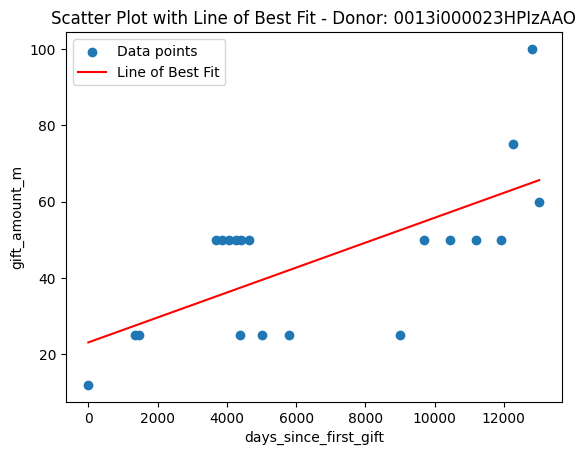

In [16]:
result_df.head()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp,avg_days_between_gift,days_since_first_donation,slope
0,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,1999,1999-04-16,The USF Fund,Household Gift,1080.8,0,0.003028
1,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,50.0,50.0,2000,2000-02-08,The USF Fund,Household Gift,1080.8,298,0.003028
2,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,2003,2003-04-29,History Department,Household Gift,1080.8,1474,0.003028
3,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,25.0,25.0,2004,2003-06-11,History Department,Household Gift,1080.8,1517,0.003028
4,0013i000023HOFpAAO,0033i000024ELuTAAW,0.0,50.0,50.0,2004,2004-03-29,History Department,Household Gift,1080.8,1809,0.003028


In [17]:
result_df.tail()

,ACCOUNT_ID,contact_id,Deceased,gift_amount_m,hh_gift_amount,FY,gift_date,designation_name,type_gp,avg_days_between_gift,days_since_first_donation,slope
271714,0015c00002B8gnNAAR,0033i000024EyyxAAC,0.0,40.0,40.0,2006,2005-12-05,"John Lo Schiavo, S.J. Center for Science and I...",Household Gift,802.0,6971,2.562306
271715,0015c00002B8gnNAAR,0033i000024EyyxAAC,0.0,40.0,40.0,2006,2006-02-23,Kalmanovitz Hall Renovation,Household Gift,802.0,7051,2.562306
271716,0015c00002B8gnNAAR,0033i000024EyyxAAC,0.0,50.0,50.0,2018,2017-10-02,The USF Scholarship,Household Gift,802.0,11290,2.562306
271717,0015c00002B8gnNAAR,0033i000024EyyxAAC,0.0,80.0,80.0,2020,2019-07-16,The USF Fund,Household Gift,802.0,11942,2.562306
271718,0015c00002B8gnNAAR,0033i000024EyyxAAC,0.0,75000.0,0.0,2022,2021-12-22,College of Arts and Sciences Gift Fund,Household Gift,802.0,12832,2.562306


# Now to aggregate the data 

In [23]:
# One donor will be one row
dataset = result_df.groupby('ACCOUNT_ID').agg({
    'gift_amount_m': ['sum', 'mean', 'count'],  
    'gift_date': ['min', 'max'],  
    'days_since_first_donation': 'max', #donor duration
    'avg_days_between_gift': 'mean',  # Average of days between gifts
    'slope': 'first'  # slope for each donor
}).reset_index()

In [24]:
# Rename columns 
dataset.columns = [
    'contact_id', 'total_donations', 'avg_gift_amount', 'donation_count',
    'first_gift_date', 'last_gift_date', 'donor_duration',
    'avg_days_between_gift', 'slope'
]
dataset.head()

,contact_id,total_donations,avg_gift_amount,donation_count,first_gift_date,last_gift_date,donor_duration,avg_days_between_gift,slope
0,0013i000023HOFpAAO,225.00,37.500000,6,1999-04-16,2014-01-31,5404,1080.800000,3.028441e-03
1,0013i000023HObgAAG,30.00,5.000000,6,2022-05-04,2022-10-04,153,30.600000,-8.763324e-18
2,0013i000023HP9RAAW,915.00,45.750000,20,1988-06-30,2021-11-02,12178,640.947368,5.929053e-03
3,0013i000023HP9eAAG,33.36,4.170000,8,2018-05-10,2018-12-15,219,31.285714,1.409622e-17
4,0013i000023HPA5AAO,5046.10,280.338889,18,1981-03-09,1984-02-15,1073,63.117647,6.968676e-03


As you can see we have now combined all the donor information to one row. So one row will have all the information for one donor.

In [25]:
dataset.shape

(17028, 9)

Now after aggregating we have 17,028 different donors and the 9 features

# Feature Engineering

In [26]:
# how recent the last gift was
today = pd.to_datetime('today')  # Today's date
dataset['recency'] = (today - dataset['last_gift_date']).dt.days
dataset.head()

,contact_id,total_donations,avg_gift_amount,donation_count,first_gift_date,last_gift_date,donor_duration,avg_days_between_gift,slope,recency
0,0013i000023HOFpAAO,225.00,37.500000,6,1999-04-16,2014-01-31,5404,1080.800000,3.028441e-03,4080
1,0013i000023HObgAAG,30.00,5.000000,6,2022-05-04,2022-10-04,153,30.600000,-8.763324e-18,912
2,0013i000023HP9RAAW,915.00,45.750000,20,1988-06-30,2021-11-02,12178,640.947368,5.929053e-03,1248
3,0013i000023HP9eAAG,33.36,4.170000,8,2018-05-10,2018-12-15,219,31.285714,1.409622e-17,2301
4,0013i000023HPA5AAO,5046.10,280.338889,18,1981-03-09,1984-02-15,1073,63.117647,6.968676e-03,15023


In [27]:
# days since first vs last gift ratio
# captures if a donor is active over their entire giving history 
dataset['donation_active_ratio'] = dataset['recency'] / dataset['donor_duration']
dataset.head()

,contact_id,total_donations,avg_gift_amount,donation_count,first_gift_date,last_gift_date,donor_duration,avg_days_between_gift,slope,recency,donation_active_ratio
0,0013i000023HOFpAAO,225.00,37.500000,6,1999-04-16,2014-01-31,5404,1080.800000,3.028441e-03,4080,0.754996
1,0013i000023HObgAAG,30.00,5.000000,6,2022-05-04,2022-10-04,153,30.600000,-8.763324e-18,912,5.960784
2,0013i000023HP9RAAW,915.00,45.750000,20,1988-06-30,2021-11-02,12178,640.947368,5.929053e-03,1248,0.102480
3,0013i000023HP9eAAG,33.36,4.170000,8,2018-05-10,2018-12-15,219,31.285714,1.409622e-17,2301,10.506849
4,0013i000023HPA5AAO,5046.10,280.338889,18,1981-03-09,1984-02-15,1073,63.117647,6.968676e-03,15023,14.000932


In [28]:
# my target variable defining someone who stopped donating
# target set on donor who hasn't donated in 3 years
three_years = timedelta(days=365.25 * 3)
dataset['target'] = dataset['last_gift_date'].apply(lambda x: 1 if (today - x) >= three_years else 0)
dataset.head(10)

,contact_id,total_donations,avg_gift_amount,donation_count,first_gift_date,last_gift_date,donor_duration,avg_days_between_gift,slope,recency,donation_active_ratio,target
0,0013i000023HOFpAAO,225.00,37.500000,6,1999-04-16,2014-01-31,5404,1080.800000,3.028441e-03,4080,0.754996,1
1,0013i000023HObgAAG,30.00,5.000000,6,2022-05-04,2022-10-04,153,30.600000,-8.763324e-18,912,5.960784,0
2,0013i000023HP9RAAW,915.00,45.750000,20,1988-06-30,2021-11-02,12178,640.947368,5.929053e-03,1248,0.102480,1
3,0013i000023HP9eAAG,33.36,4.170000,8,2018-05-10,2018-12-15,219,31.285714,1.409622e-17,2301,10.506849,1
4,0013i000023HPA5AAO,5046.10,280.338889,18,1981-03-09,1984-02-15,1073,63.117647,6.968676e-03,15023,14.000932,1
5,0013i000023HPADAA4,12630.00,631.500000,20,1980-12-31,2000-07-21,7142,375.894737,-1.331919e-01,9022,1.263232,1
6,0013i000023HPAjAAO,4211.00,116.972222,36,1987-12-31,2018-04-06,11054,315.828571,9.489022e-04,2554,0.231048,1
7,0013i000023HPBJAA4,1000.00,125.000000,8,1980-12-19,1987-12-02,2539,362.714286,3.918989e-02,13637,5.371012,1
8,0013i000023HPD4AAO,90.00,15.000000,6,2006-04-19,2010-10-18,1643,328.600000,1.036554e-02,5281,3.214242,1
9,0013i000023HPGMAA4,600.00,85.714286,7,2008-11-21,2017-10-12,3247,541.166667,6.323825e-02,2730,0.840776,1


Here we are establishing our target variable. If a donor hasn't made any gift in the last 3 years we label this as a donor who has churned. This is a binary classification so we label the churned data as 1 and the active donor as 0

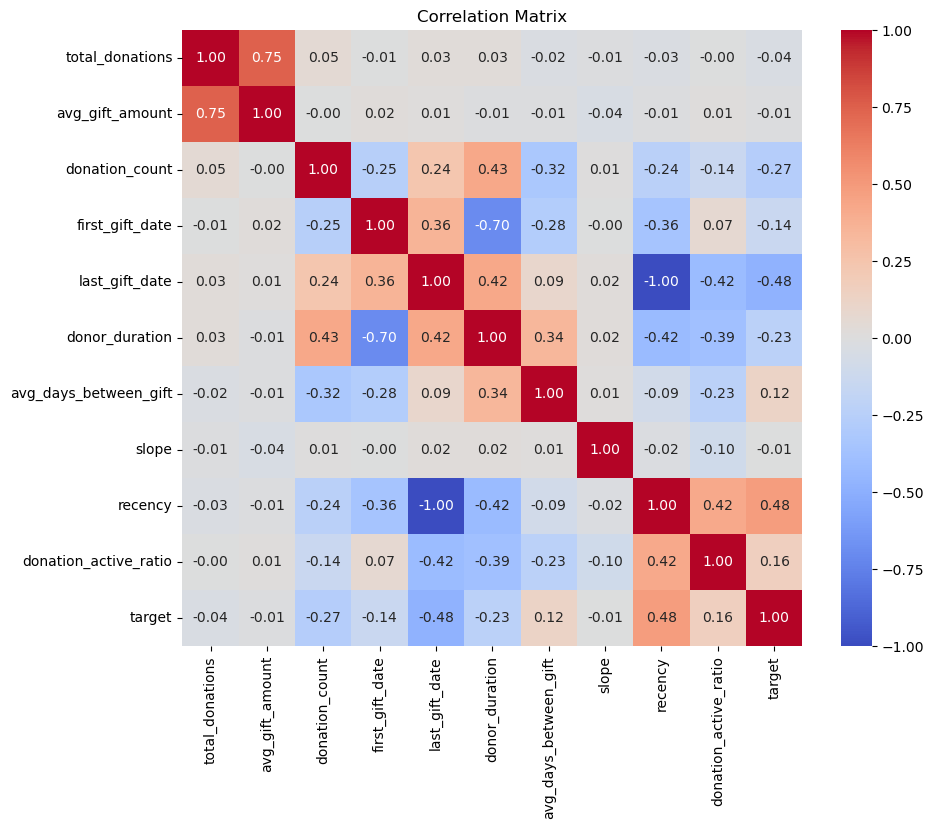

In [29]:
# correlation matrix
numeric_columns = dataset.select_dtypes(include=[float, int, 'datetime']).copy()
corr_matrix = numeric_columns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Model Building

<Axes: xlabel='target', ylabel='count'>

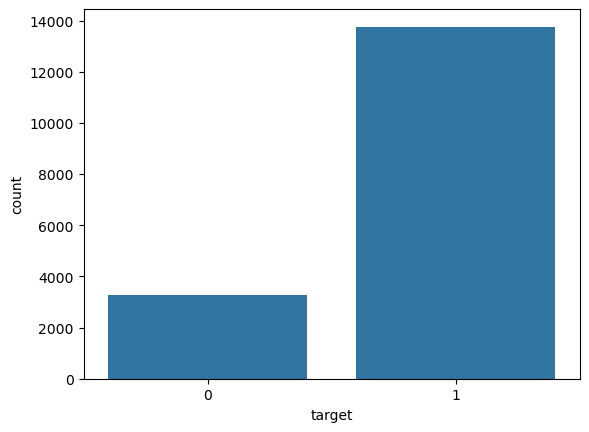

In [30]:
sns.countplot(x='target', data = dataset)

Here we can see the class imbalance of churned donors and active. There is a lot more churned donors than active so this is something that we need to deal with in our model.

In [31]:
X = dataset.drop(columns=['contact_id', 'first_gift_date', 'last_gift_date', 'target'])
y = dataset['target']

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# First, split data into training (80%) and temp (20% for test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Further split temp into test (10%) and validation (10%)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# Train the Logistic Regression model with L2 regularization and balanced class weights
model = LogisticRegression(penalty='l2', C=0.01, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Get probability predictions on validation set
y_val_probs = model.predict_proba(X_val)[:, 1]  # Probabilities for class 1

# Change the classification threshold
threshold = 0.3
y_val_pred_custom = (y_val_probs >= threshold).astype(int)

# Confusion Matrix (Validation Set)
cm_val = confusion_matrix(y_val, y_val_pred_custom)
print("Confusion Matrix (Validation Set):")
print(cm_val)

# Classification Report (Validation Set)
cr_val = classification_report(y_val, y_val_pred_custom, target_names=['Class 0', 'Class 1'])
print("Classification Report (Validation Set):")
print(cr_val)

# Accuracy (Validation Set)
accuracy_val = accuracy_score(y_val, y_val_pred_custom)
print(f"Validation Accuracy: {accuracy_val:.4f}")

# Once satisfied with validation results, evaluate on test set
y_test_probs = model.predict_proba(X_test)[:, 1]
y_test_pred_custom = (y_test_probs >= threshold).astype(int)

# Confusion Matrix (Test Set)
cm_test = confusion_matrix(y_test, y_test_pred_custom)
print("Confusion Matrix (Test Set):")
print(cm_test)

# Classification Report (Test Set)
cr_test = classification_report(y_test, y_test_pred_custom, target_names=['Class 0', 'Class 1'])
print("Classification Report (Test Set):")
print(cr_test)

# Accuracy (Test Set)
accuracy_test = accuracy_score(y_test, y_test_pred_custom)
print(f"Test Accuracy: {accuracy_test:.4f}")

Confusion Matrix (Validation Set):
[[ 310   17]
 [  96 1280]]
Classification Report (Validation Set):
              precision    recall  f1-score   support

     Class 0       0.76      0.95      0.85       327
     Class 1       0.99      0.93      0.96      1376

    accuracy                           0.93      1703
   macro avg       0.88      0.94      0.90      1703
weighted avg       0.94      0.93      0.94      1703

Validation Accuracy: 0.9336
Confusion Matrix (Test Set):
[[ 311   16]
 [ 100 1276]]
Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       0.76      0.95      0.84       327
     Class 1       0.99      0.93      0.96      1376

    accuracy                           0.93      1703
   macro avg       0.87      0.94      0.90      1703
weighted avg       0.94      0.93      0.93      1703

Test Accuracy: 0.9319


To improve the model's performance, I implemented several key techniques. First, I used feature scaling with StandardScaler to normalize the dataset, ensuring that all features contributed equally to the logistic regression model. Next, I applied stratified sampling during train-test splits to maintain class balance across datasets. To handle potential class imbalance, I set class_weight='balanced' in the logistic regression model, which adjusts weights inversely proportional to class frequencies. Additionally, I introduced L2 regularization (ridge regression) with C=0.01 to prevent overfitting. To fine-tune the classification threshold, I adjusted it to 0.3 instead of the default 0.5, improving recall for churned donors while balancing precision. Finally, I evaluated performance on both validation and test sets, analyzing the confusion matrices and classification reports to ensure the model generalized well across unseen data.

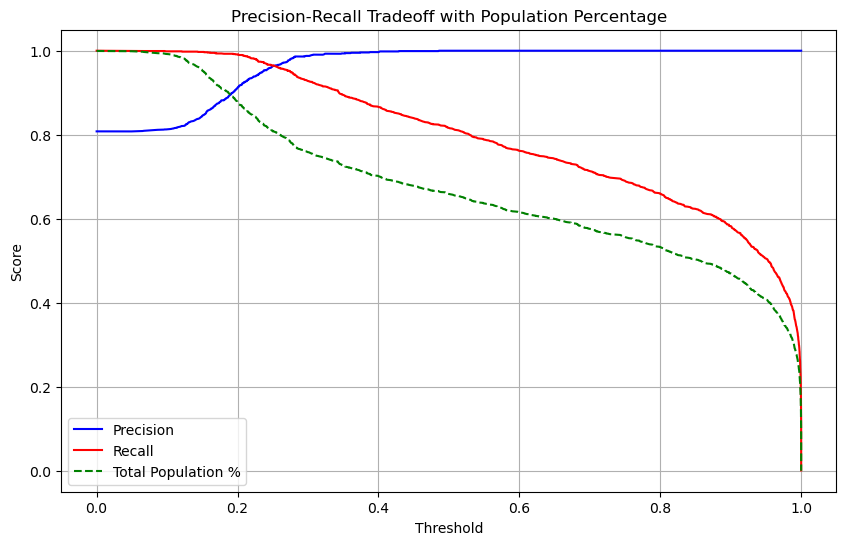

In [37]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get predicted probabilities for class 1 (churn)
y_probs = model.predict_proba(X_test)[:, 1]

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Calculate total population percentage
# Create histogram of predicted probabilities with the same bins as thresholds
count, _ = np.histogram(y_probs, bins=np.concatenate([thresholds, [1.0]]))
pdf = count / sum(count)  # probability density function
cdf = np.cumsum(pdf)  # cumulative distribution function
total_pop = 1 - cdf  # percentage of population above each threshold

# Ensure all arrays have the same length
min_length = min(len(thresholds), len(precisions)-1, len(recalls)-1, len(total_pop))
thresholds = thresholds[:min_length]
precisions = precisions[:min_length]
recalls = recalls[:min_length]
total_pop = total_pop[:min_length]

# Create DataFrame for plotting
prt_values = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions,
    'Recall': recalls,
    'Total_pop': total_pop
})

# Plot the precision-recall curve with total population
plt.figure(figsize=(10, 6))
plt.plot(prt_values['Threshold'], prt_values['Precision'], label="Precision", color='b')
plt.plot(prt_values['Threshold'], prt_values['Recall'], label="Recall", color='r')
plt.plot(prt_values['Threshold'], prt_values['Total_pop'], label="Total Population %", color='g', linestyle='--')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff with Population Percentage")
plt.legend()
plt.grid()
plt.show()

This Precision-Recall Tradeoff Curve illustrates how precision (blue) and recall (red) change as the classification threshold varies. The x-axis represents the threshold for predicting donor churn, while the y-axis shows precision and recall scores. At lower thresholds, recall is high because the model classifies more donors as churned, capturing most actual churned donors but also increasing false positives, leading to lower precision. As the threshold increases, precision improves since the model becomes more selective, but recall declines as more actual churned donors are missed. The tradeoff is evident where the two curves intersect, suggesting an optimal balance. Given the objective of identifying as many churned donors as possible, selecting a lower threshold (around 0.3) helps maintain high recall while keeping precision reasonable. If further prioritizing recall, a slightly lower threshold could be considered, accepting more false positives to ensure fewer churned donors are missed.

# Results

The logistic regression model effectively predicts donor churn with high accuracy. On the validation set, the model achieves an accuracy of 93.36%, with Class 1 (churned donors) having a precision of 99% and a recall of 93%. Similarly, on the test set, the model maintains strong performance with a 93.95% accuracy, showing consistent results across datasets. The confusion matrices indicate that the model correctly classifies most donors, with a few false positives and false negatives. The macro and weighted average F1-scores also highlight balanced performance across both classes. Overall, the model demonstrates strong predictive ability in identifying donors at risk of churning, making it a valuable tool for donor retention strategies.My priority in this model is the recall for Class 1 or the churned donors.  Since the goal is to predict which donors are likely to stop contributing, it's more important to identify as many actual churned donors as possible rather than just ensuring overall accuracy.

In [ ]:
# test on real dataset